# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp
import torch.nn as nn

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer 
from KoopmanTrainer_AFT import Trainer as Trainer_AFT
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet
#from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


In [ ]:
import torch
import torch.nn as nn

class AttentionFreeTransformer(nn.Module):
    def __init__(self, d_model, max_seq_len, device):
        super().__init__()
        self.d_model = d_model
        self.device = device
        self.max_seq_len = max_seq_len

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.position_bias = nn.Parameter(torch.randn(max_seq_len, max_seq_len))
        mask = torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        self.register_buffer('mask', mask)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        Returns: (batch, d_model)  # only the last timestep
        """
        B, T, D = x.size()
        assert D == self.d_model, "Input dim mismatch"

        q = torch.sigmoid(self.Wq(x))      # (B, T, D)
        k = self.Wk(x) / (self.d_model ** 0.5)   # (B, T, D)
        v = self.Wv(x) / (self.d_model ** 0.5)   # (B, T, D)

        w = self.position_bias[:T, :T]     # (T, T)

        k_exp = k.unsqueeze(1)             # (B, 1, T, D)
        v_exp = v.unsqueeze(1)             # (B, 1, T, D)
        w_exp = w.unsqueeze(0).unsqueeze(-1)  # (1, T, T, 1)

        k_biased = k_exp + w_exp           # (B, T, T, D)
        exp_k = torch.exp(k_biased)        # (B, T, T, D)

        m = self.mask[:T, :T]              # (T, T)
        m_exp = m.unsqueeze(0).unsqueeze(-1)  # (1, T, T, 1)
        exp_k = exp_k.masked_fill(m_exp, 0.0)

        num = (exp_k * v_exp).sum(dim=2)   # (B, T, D)
        denom = exp_k.sum(dim=2)           # (B, T, D)
        y = q * (num / (denom + 1e-8))     # (B, T, D)

        return y[:, -1, :]                 # return only last timestep

## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [3]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [4]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [8]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'isolated_repressilator'
args.folder = 'isolated_repressilator_AFTvsnonAFT'
args.time_steps = 201
args.prediction_length = 200
args.max_time = 40
args.num_samples = 15000
args.bottleneck = 100
args.decoder_loss_weight = 10
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.save = False


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [9]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [10]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 15000/15000 [00:00<00:00, 41480.81it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTens

the shape of the data is torch.Size([15000, 201, 6])
Processing dataset: isolated_repressilator
train_idx: 12000, val_idx: 13500
Processed data shapes - Train: torch.Size([12000, 201, 6]), Val: torch.Size([1500, 201, 6]), Test: torch.Size([1500, 201, 6])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [11]:
# Model definition with bottleneck size 100

def Koopman(bottleneck_size):
    # Define the AutoEncoder and Knet models
    ae = AutoEncoder(
        input_size=input_size,
        encoded_size=bottleneck_size,
        encoder_hidden_layers=args.encoder_hidden_layers,
        decoder_hidden_layers=args.decoder_hidden_layers,
        network_type=args.network_type,
        batch_norm=False
    )
    knet = Knet(size=bottleneck_size)
    model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
    return model

def KoopmanAFT(bottleneck_size):
    # Define the AutoEncoder and Knet models
    ae = AutoEncoder(
        input_size=input_size,
        encoded_size=bottleneck_size,
        encoder_hidden_layers=args.encoder_hidden_layers,
        decoder_hidden_layers=args.decoder_hidden_layers,
        network_type=args.network_type,
        batch_norm=False
    )
    knet = Knet(size=bottleneck_size)
    AFT = AttentionFreeTransformer(d_model=bottleneck_size, max_seq_len=args.context_length, device=device)
    model = torch.nn.ModuleDict({'ae': ae, 'knet': knet, 'aft_layer': AFT})
    return model

# creating models without AFT
model_100 = Koopman(100)
model_100 = model_100.to(device)
print("Created model_100 with bottleneck size 100")
model_75 = Koopman(75)
model_75 = model_75.to(device)
print("Created model_75 with bottleneck size 75")
model_50 = Koopman(50)
model_50 = model_50.to(device)
print("Created model_50 with bottleneck size 50")
model_25 = Koopman(25)
model_25 = model_25.to(device)  
print("Created model_25 with bottleneck size 25")
# creating models with AFT
model_100_AFT = KoopmanAFT(100)
model_100_AFT = model_100_AFT.to(device)
print("Created model_100_AFT with bottleneck size 100")
model_75_AFT = KoopmanAFT(75)
model_75_AFT = model_75_AFT.to(device)
print("Created model_75_AFT with bottleneck size 75")
model_50_AFT = KoopmanAFT(50)
model_50_AFT = model_50_AFT.to(device)
print("Created model_50_AFT with bottleneck size 50")
model_25_AFT = KoopmanAFT(25)
model_25_AFT = model_25_AFT.to(device)
print("Created model_25_AFT with bottleneck size 25")

Created model_100 with bottleneck size 100
Created model_75 with bottleneck size 75
Created model_50 with bottleneck size 50
Created model_25 with bottleneck size 25
Created model_100_AFT with bottleneck size 100
Created model_75_AFT with bottleneck size 75
Created model_50_AFT with bottleneck size 50
Created model_25_AFT with bottleneck size 25


## Model Summary

Display the total number of parameters and the model architecture.

In [12]:

print('**** Models without AFT ****')
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_100.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_100.parameters())/1000.0))
print('************')
# model 75
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_75.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_75.parameters())/1000.0))
print('************')
# model 50
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_50.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_50.parameters())/1000.0))
print('************')
# model 25
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_25.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_25.parameters())/1000.0))
print('************')

print('**** Models with AFT ****')
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_100_AFT.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_100_AFT.parameters())/1000.0))
print('************')
# model 75
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_75_AFT.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_75_AFT.parameters())/1000.0))
print('************')
# model 50
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_50_AFT.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_50_AFT.parameters())/1000.0))
print('************')
# model 25
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_25_AFT.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_25_AFT.parameters())/1000.0))
print('************')

**** Models without AFT ****
**** Setup ****
Total params: 0.05M
Total params: 51.71k
************
**** Setup ****
Total params: 0.04M
Total params: 42.31k
************
**** Setup ****
Total params: 0.03M
Total params: 34.16k
************
**** Setup ****
Total params: 0.03M
Total params: 27.26k
************
**** Models with AFT ****
**** Setup ****
Total params: 0.08M
Total params: 82.11k
************
**** Setup ****
Total params: 0.06M
Total params: 59.51k
************
**** Setup ****
Total params: 0.04M
Total params: 41.91k
************
**** Setup ****
Total params: 0.03M
Total params: 29.31k
************


## Training

Train the model using the `Trainer` class with the specified data loaders.

In [13]:
print('**** Creating Trainer for models without AFT ****')
trainer_100 = Trainer(model_100, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_75 = Trainer(model_75, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_50 = Trainer(model_50, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_25 = Trainer(model_25, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

print('**** Creating Trainer for models with AFT ****')
trainer_100_AFT = Trainer_AFT(model_100_AFT, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_75_AFT = Trainer_AFT(model_75_AFT, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_50_AFT = Trainer_AFT(model_50_AFT, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_25_AFT = Trainer_AFT(model_25_AFT, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

**** Creating Trainer for models without AFT ****
Using the CPU
Using the CPU
Using the CPU
Using the CPU
**** Creating Trainer for models with AFT ****
Using the CPU
Using the CPU
Using the CPU
Using the CPU


In [14]:
print("*****************************************************************")
print("Training models with AFT...")
print("Training model with bottleneck size 100")
stats_100_AFT = trainer_100_AFT.train_KoopmanAE()[2]
print("Training model with bottleneck size 75")
stats_75_AFT = trainer_75_AFT.train_KoopmanAE()[2]
print("Training model with bottleneck size 50")
stats_50_AFT = trainer_50_AFT.train_KoopmanAE()[2]
print("Training model with bottleneck size 25")
stats_25_AFT = trainer_25_AFT.train_KoopmanAE()[2]

*****************************************************************
Training models with AFT...
Training model with bottleneck size 100


Training Epochs:   5%|▌         | 5/100 [09:23<2:55:52, 111.08s/it]

Epoch 5/100
Training - Recon Loss: 5.110175e-05, Linear Loss: 2.527769e-04, Pred Loss: 2.062918e-03, Unitary Loss: 6.910083e-06, Total Loss: 2.146207e-02
Validation - Recon Loss: 5.164372e-05, Linear Loss: 1.746401e-04, Pred Loss: 1.961041e-03,Unitary Loss: 7.140371e-06, Total Loss: 2.030148e-02


Training Epochs:  10%|█         | 10/100 [18:06<2:37:31, 105.02s/it]

Epoch 10/100
Training - Recon Loss: nan, Linear Loss: nan, Pred Loss: nan, Unitary Loss: nan, Total Loss: nan
Validation - Recon Loss: nan, Linear Loss: nan, Pred Loss: nan,Unitary Loss: nan, Total Loss: nan


Training Epochs:  10%|█         | 10/100 [18:12<2:43:53, 109.26s/it]


KeyboardInterrupt: 

In [11]:
print("Training models without AFT...")
print("Training model with bottleneck size 100")
stats_100 = trainer_100.train_KoopmanAE()[2]
print("Training model with bottleneck size 75")
stats_75 = trainer_75.train_KoopmanAE()[2]
print("Training model with bottleneck size 50")
stats_50 = trainer_50.train_KoopmanAE()[2]
print("Training model with bottleneck size 25")
stats_25 = trainer_25.train_KoopmanAE()[2]

Training models without AFT...
Training model with bottleneck size 100


Training Epochs:  20%|██        | 20/100 [09:32<38:38, 28.98s/it]

Epoch 20/100
Training - Recon Loss: 6.328673e-05, Linear Loss: 3.308321e-04, Pred Loss: 1.017365e-03, Unitary Loss: 5.236751e-04, Total Loss: 1.637410e-02
Validation - Recon Loss: 4.445222e-05, Linear Loss: 3.562562e-04, Pred Loss: 9.106810e-04,Unitary Loss: 5.230892e-04, Total Loss: 9.907588e-03


Training Epochs:  40%|████      | 40/100 [19:13<29:10, 29.17s/it]

Epoch 40/100
Training - Recon Loss: 5.780628e-05, Linear Loss: 2.955594e-04, Pred Loss: 5.856242e-04, Unitary Loss: 4.960427e-04, Total Loss: 1.169029e-02
Validation - Recon Loss: 2.952397e-05, Linear Loss: 2.200729e-04, Pred Loss: 4.621205e-04,Unitary Loss: 4.949943e-04, Total Loss: 5.136517e-03


...

Epoch 60/100
Training - Recon Loss: 1.585747e-04, Linear Loss: 3.769107e-04, Pred Loss: 7.510599e-04, Unitary Loss: 4.226615e-05, Total Loss: 9.895918e-03
Validation - Recon Loss: 1.131644e-04, Linear Loss: 2.522184e-04, Pred Loss: 6.500213e-04,Unitary Loss: 3.981224e-05, Total Loss: 7.884076e-03


Training Epochs:  80%|████████  | 80/100 [12:25<03:06,  9.34s/it]

Epoch 80/100
Training - Recon Loss: 1.411345e-04, Linear Loss: 3.928761e-04, Pred Loss: 7.119860e-04, Unitary Loss: 4.447413e-05, Total Loss: 9.368823e-03
Validation - Recon Loss: 9.946011e-05, Linear Loss: 2.919147e-04, Pred Loss: 6.511060e-04,Unitary Loss: 4.482635e-05, Total Loss: 7.797575e-03


Training Epochs: 100%|██████████| 100/100 [15:33<00:00,  9.33s/it]

Epoch 100/100
Training - Recon Loss: 1.264170e-04, Linear Loss: 3.881932e-04, Pred Loss: 6.482078e-04, Unitary Loss: 4.771563e-05, Total Loss: 8.611598e-03
Validation - Recon Loss: 8.437373e-05, Linear Loss: 3.303763e-04, Pred Loss: 5.470575e-04,Unitary Loss: 5.032018e-05, Total Loss: 6.644688e-03


In [13]:
# saving the stats and the models in pkl format
stats = {
    'stats_100': stats_100,
    'stats_75': stats_75,
    'stats_50': stats_50,
    'stats_25': stats_25,
    'stats_100_AFT': stats_100_AFT,
    'stats_75_AFT': stats_75_AFT,
    'stats_50_AFT': stats_50_AFT,
    'stats_25_AFT': stats_25_AFT
}

for key, value in stats.items():
    print(f"{key}: {value}")
    torch.save(value, os.path.join('experiments', args.folder,f"{key}.pkl"))

# Save the models
torch.save(trainer_100.model.state_dict(), os.path.join('experiments', args.folder, 'model_100.pkl'))
torch.save(trainer_75.model.state_dict(), os.path.join('experiments', args.folder, 'model_75.pkl'))
torch.save(trainer_50.model.state_dict(), os.path.join('experiments', args.folder, 'model_50.pkl'))
torch.save(trainer_25.model.state_dict(), os.path.join('experiments', args.folder, 'model_25.pkl'))
torch.save(trainer_100_AFT.model.state_dict(), os.path.join('experiments', args.folder, 'model_100_AFT.pkl'))
torch.save(trainer_75_AFT.model.state_dict(), os.path.join('experiments', args.folder, 'model_75_AFT.pkl'))
torch.save(trainer_50_AFT.model.state_dict(), os.path.join('experiments', args.folder, 'model_50_AFT.pkl'))
torch.save(trainer_25_AFT.model.state_dict(), os.path.join('experiments', args.folder, 'model_25_AFT.pkl'))



stats_100: {'recon_loss_tr': [0.002034986993555534, 7.18499228009642e-05, 5.151786888049212e-05, 6.61693578722213e-05, 6.047180493701586e-05, 5.552212837272314e-05, 5.6334327963029746e-05, 6.73044474326084e-05, 6.137152144838957e-05, 7.556430632285675e-05, 6.585131690216974e-05, 6.518627061326542e-05, 7.231467083948566e-05, 6.712004022197203e-05, 6.445495660529482e-05, 5.7492805237725793e-05, 5.866734724630542e-05, 6.420577696228569e-05, 6.079077498493171e-05, 6.32867318695099e-05, 6.550600266293375e-05, 5.9543096288875184e-05, 7.146464826717497e-05, 7.19307239357496e-05, 5.583842756366605e-05, 5.55326046680343e-05, 6.740542708127017e-05, 6.31363918921821e-05, 5.799726216324377e-05, 5.465840478520593e-05, 5.723575432444278e-05, 5.961357682610198e-05, 5.446667316217381e-05, 6.105575231869923e-05, 6.176104154214858e-05, 5.7855404172206615e-05, 5.9134779532657974e-05, 6.140342969608374e-05, 5.122973557940605e-05, 5.780627771913559e-05, 5.736602810081441e-05, 5.35727816741007e-05, 6.829963

In [14]:

print("Testing models without AFT...")
print("Testing model with bottleneck size 100")
trainer_100.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 75")
trainer_75.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 50")
trainer_50.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 25")
trainer_25.test_KoopmanAE(test_loader)

print("Testing models with AFT...")
print("Testing model with bottleneck size 100")
trainer_100_AFT.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 75")
trainer_75_AFT.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 50")
trainer_50_AFT.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 25")
trainer_25_AFT.test_KoopmanAE(test_loader)

Testing models without AFT...
Testing model with bottleneck size 100
Test - Recon Loss: 2.093264e-05, Linear Loss: 1.086308e-04, Pred Loss: 3.471456e-04, Total Loss: 3.789413e-03
Testing model with bottleneck size 75
Test - Recon Loss: 3.092353e-05, Linear Loss: 2.117415e-04, Pred Loss: 3.179042e-04, Total Loss: 3.700019e-03
Testing model with bottleneck size 50
Test - Recon Loss: 5.072483e-05, Linear Loss: 1.736491e-04, Pred Loss: 3.031810e-04, Total Loss: 3.712708e-03
Testing model with bottleneck size 25
Test - Recon Loss: 8.555988e-05, Linear Loss: 3.622828e-04, Pred Loss: 5.593221e-04, Total Loss: 6.811102e-03
Testing models with AFT...
Testing model with bottleneck size 100
Test - Recon Loss: 1.071048e-05, Linear Loss: 2.135580e-04, Pred Loss: 2.251799e-04, Total Loss: 2.572462e-03
Testing model with bottleneck size 75
Test - Recon Loss: 1.654691e-05, Linear Loss: 1.812686e-04, Pred Loss: 2.305837e-04, Total Loss: 2.652575e-03
Testing model with bottleneck size 50
Test - Recon Lo

## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

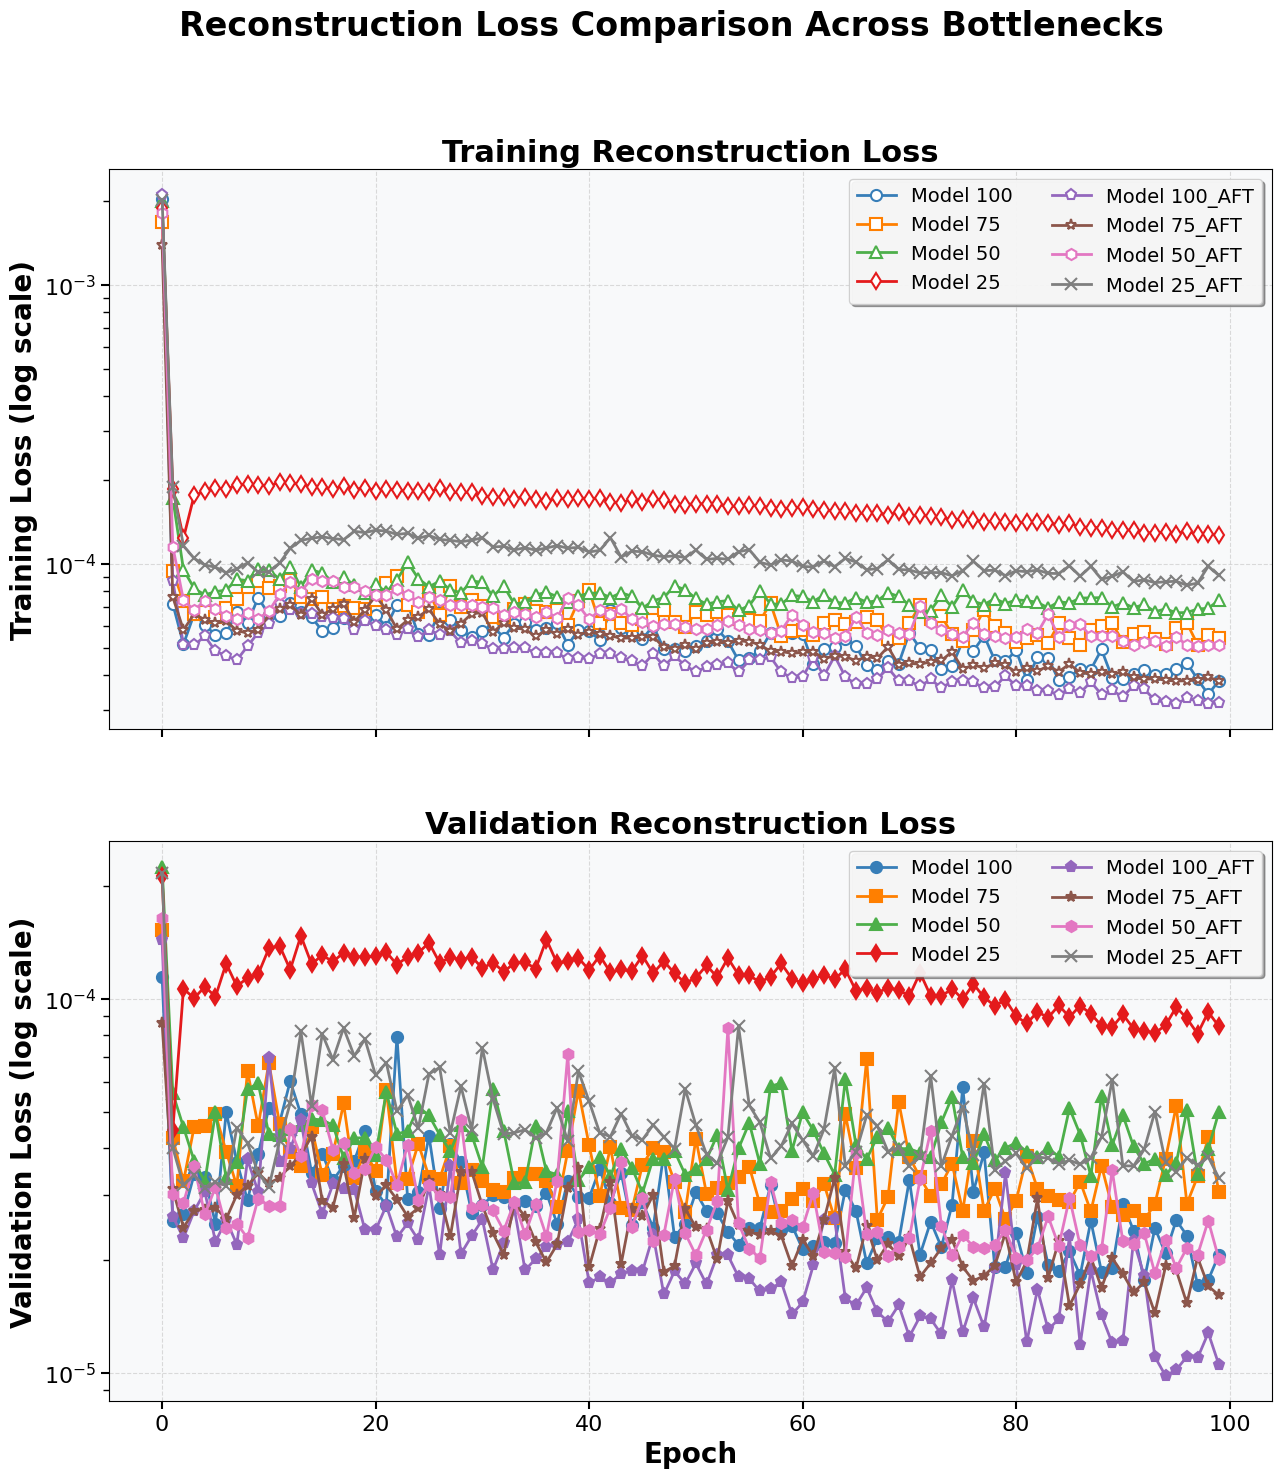

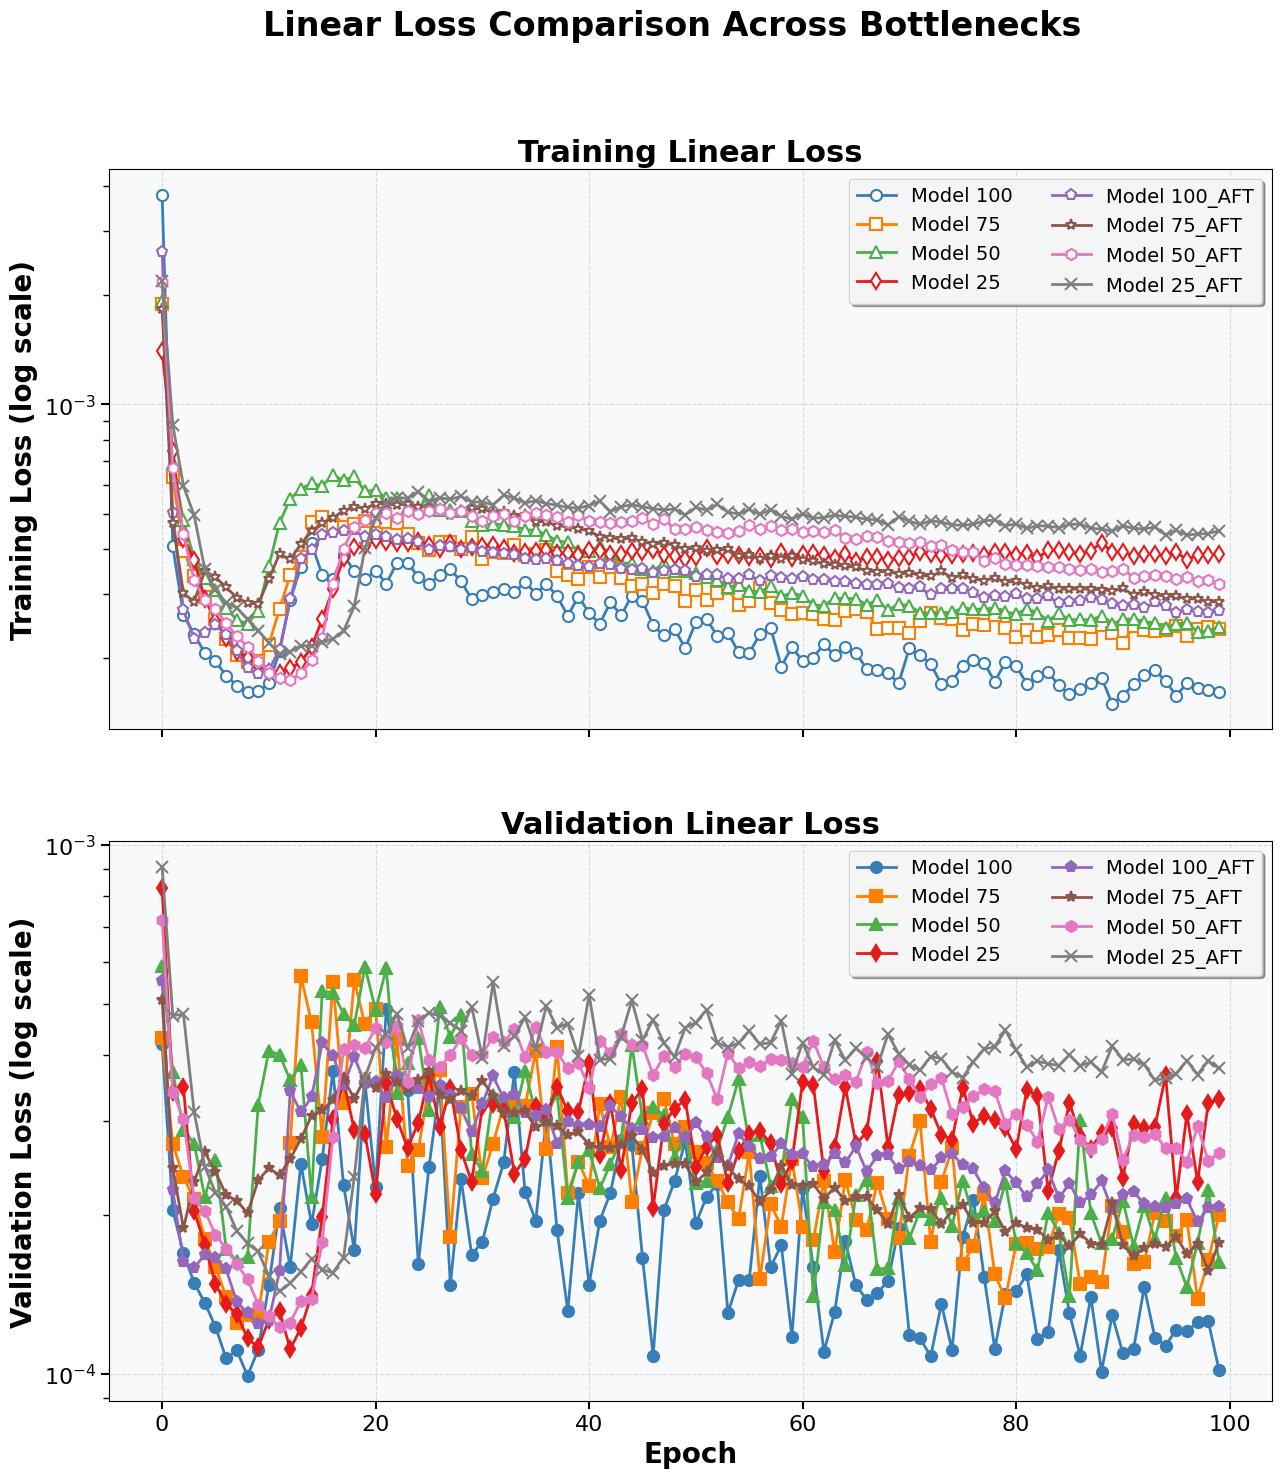

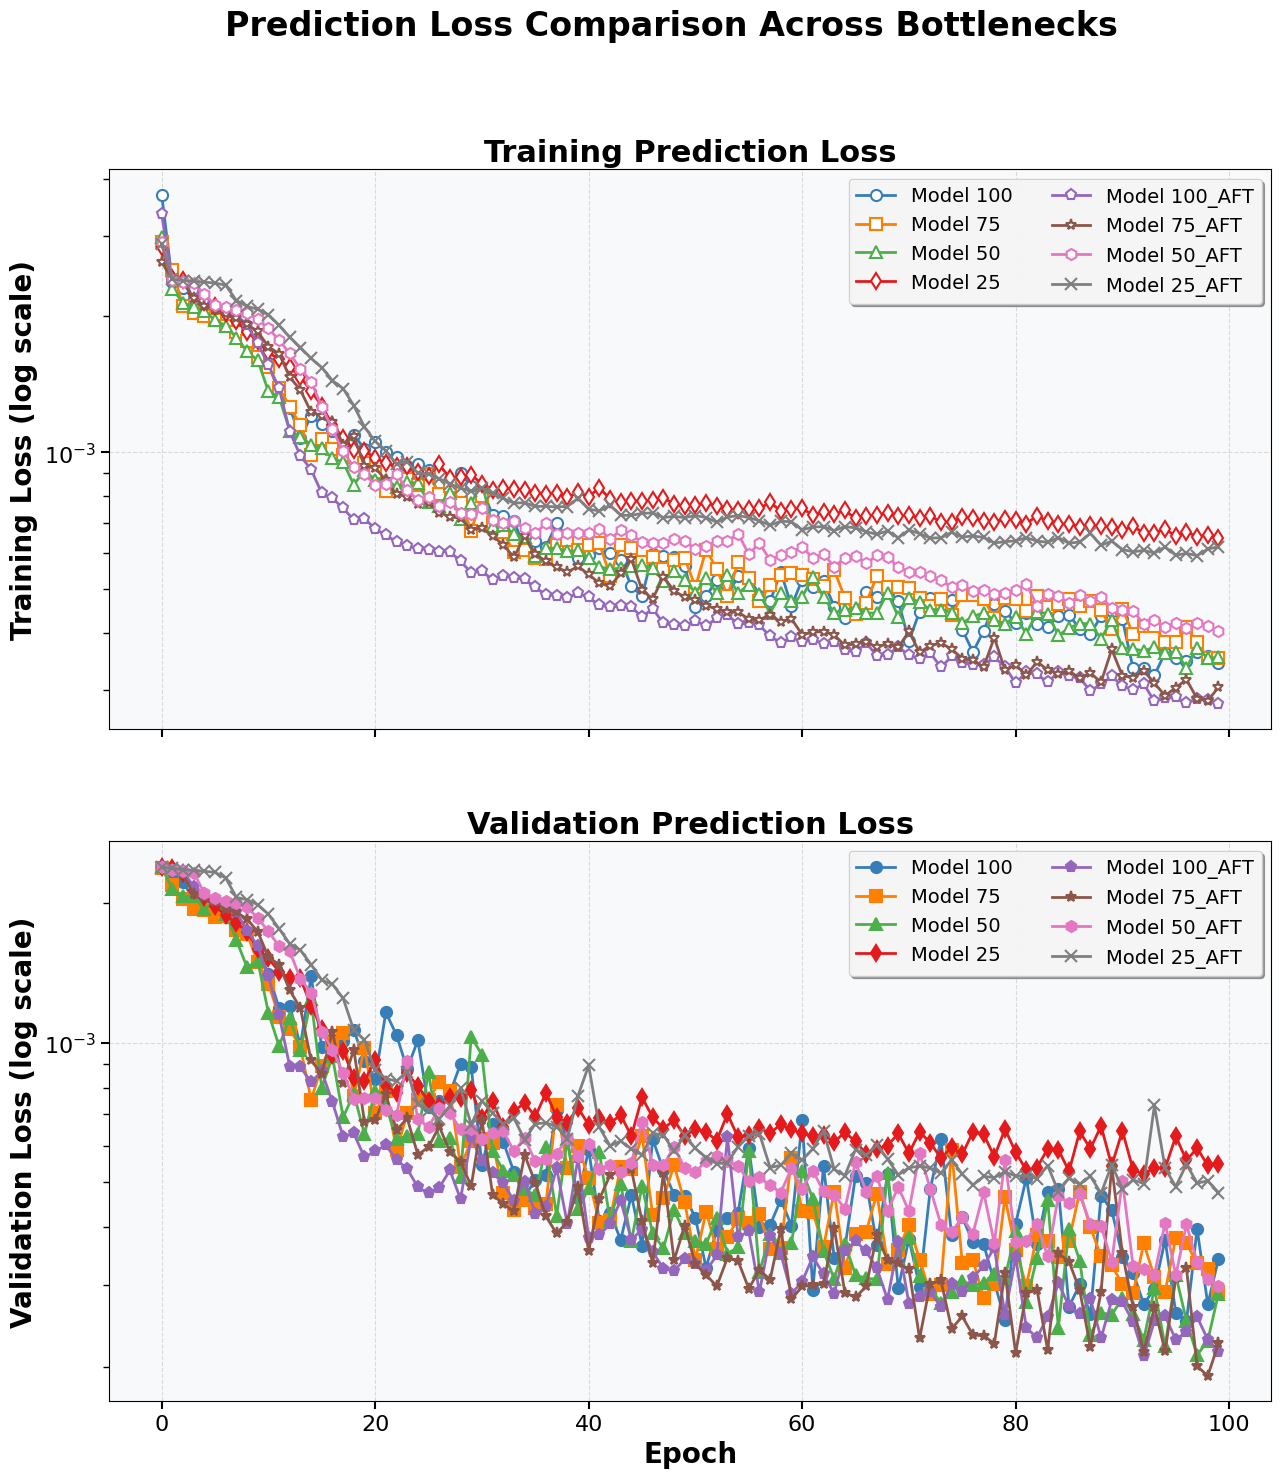

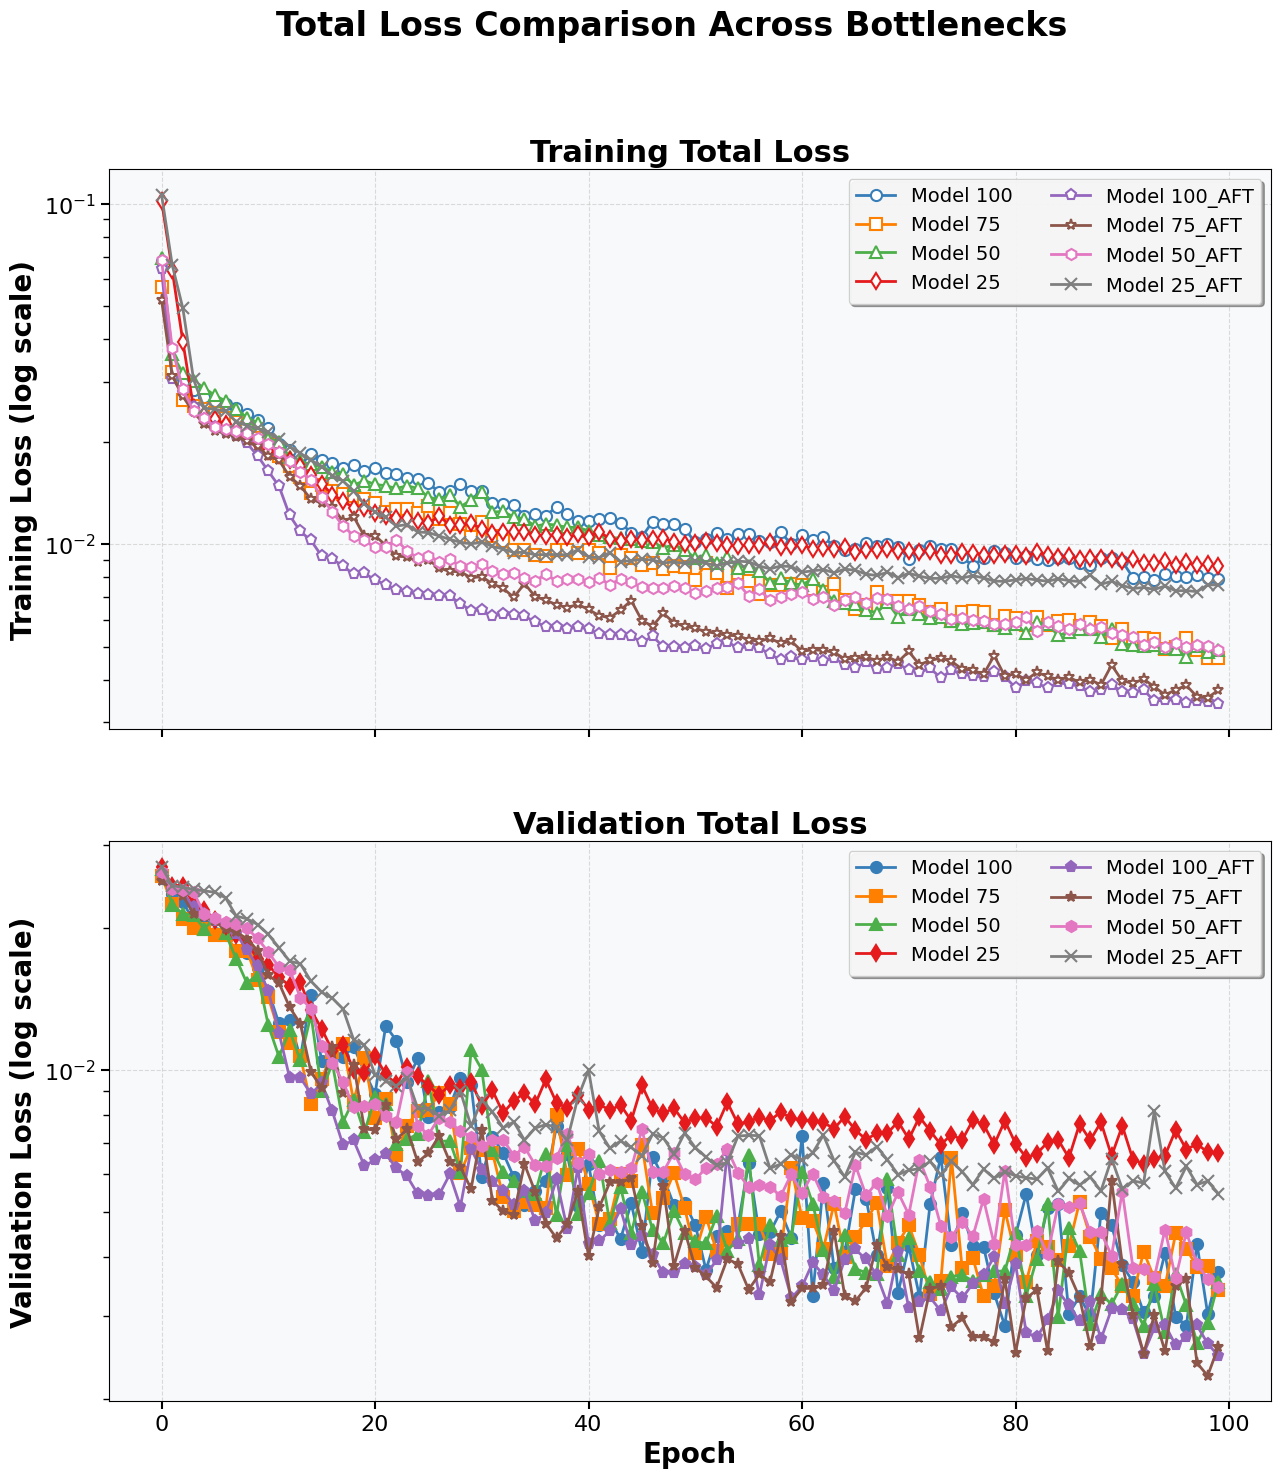

Generated separated comparison loss plots.


In [15]:
def plot_comparison_losses_separated(stats_dict, loss_base_name, folder_path, save=True):
    """
    Plots training and validation losses for a specific loss type across multiple models,
    with training and validation on separate subplots.

    Args:
        stats_dict (dict): A dictionary where keys are model identifiers (e.g., '100', '75')
                           and values are the corresponding stats dictionaries from training.
        loss_base_name (str): The base name of the loss (e.g., 'recon_loss', 'lin_loss').
        folder_path (str): Path to the folder where the plot should be saved.
        save (bool): Whether to save the plot.
    """
    fig, (ax_train, ax_val) = plt.subplots(2, 1, figsize=(15, 16), sharex=True)
    
    colors = {'100': '#377eb8', '75': '#ff7f00', '50': '#4daf4a', '25': '#e41a1c',
              '100_AFT': '#9467bd', '75_AFT': '#8c564b', '50_AFT': '#e377c2', '25_AFT': '#7f7f7f'}
    markers = {'100': 'o', '75': 's', '50': '^', '25': 'd',
               '100_AFT': 'p', '75_AFT': '*', '50_AFT': 'h', '25_AFT': 'x'}
    
    loss_title_map = {
        'recon_loss': 'Reconstruction',
        'lin_loss': 'Linear',
        'pred_loss': 'Prediction',
        'total_loss': 'Total'
    }
    plot_title = loss_title_map.get(loss_base_name, loss_base_name.replace('_', ' ').title())

    # Plot training losses
    for model_id, stats in stats_dict.items():
        loss_tr_key = f'{loss_base_name}_tr'
        
        if loss_tr_key in stats:
            loss_tr = np.array(stats[loss_tr_key])
            # Handle potential non-positive values for log scale
            if np.any(loss_tr <= 0):
                min_positive = np.min(loss_tr[loss_tr > 0]) / 10 if np.any(loss_tr > 0) else 1e-10
                loss_tr = np.maximum(loss_tr, min_positive)
            
            ax_train.semilogy(loss_tr, lw=2, marker=markers[model_id], markersize=8,
                             markerfacecolor='white', markeredgewidth=1.5,
                             markeredgecolor=colors[model_id], linestyle='-',
                             label=f'Model {model_id}', color=colors[model_id])

    # Plot validation losses
    for model_id, stats in stats_dict.items():
        loss_va_key = f'{loss_base_name}_va'
        
        if loss_va_key in stats:
            loss_va = np.array(stats[loss_va_key])
            # Handle potential non-positive values for log scale
            if np.any(loss_va <= 0):
                min_positive = np.min(loss_va[loss_va > 0]) / 10 if np.any(loss_va > 0) else 1e-10
                loss_va = np.maximum(loss_va, min_positive)
            
            ax_val.semilogy(loss_va, lw=2, marker=markers[model_id], markersize=8,
                           markerfacecolor=colors[model_id], markeredgewidth=1.5,
                           markeredgecolor=colors[model_id], linestyle='-',
                           label=f'Model {model_id}', color=colors[model_id])

    # Style training plot
    ax_train.grid(True, linestyle='--', alpha=0.7, color='#cccccc')
    ax_train.tick_params(axis='both', which='major', labelsize=16, width=1.5, length=6)
    ax_train.tick_params(axis='both', which='minor', width=1, length=4)
    ax_train.set_ylabel('Training Loss (log scale)', fontsize=20, fontweight='bold')
    ax_train.set_title(f'Training {plot_title} Loss', fontsize=22, fontweight='bold')
    ax_train.set_facecolor('#f8f9fa')
    ax_train.legend(fontsize=14, frameon=True, fancybox=True, framealpha=0.9,
                   shadow=True, loc='upper right', ncol=2)
    ax_train.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=np.arange(1, 10)*0.1))

    # Style validation plot
    ax_val.grid(True, linestyle='--', alpha=0.7, color='#cccccc')
    ax_val.tick_params(axis='both', which='major', labelsize=16, width=1.5, length=6)
    ax_val.tick_params(axis='both', which='minor', width=1, length=4)
    ax_val.set_ylabel('Validation Loss (log scale)', fontsize=20, fontweight='bold')
    ax_val.set_xlabel('Epoch', fontsize=20, fontweight='bold')
    ax_val.set_title(f'Validation {plot_title} Loss', fontsize=22, fontweight='bold')
    ax_val.set_facecolor('#f8f9fa')
    ax_val.legend(fontsize=14, frameon=True, fancybox=True, framealpha=0.9,
                 shadow=True, loc='upper right', ncol=2)
    ax_val.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=np.arange(1, 10)*0.1))

    # Main title
    fig.suptitle(f'{plot_title} Loss Comparison Across Bottlenecks', fontsize=24, 
                fontweight='bold', y=0.98)

    # Save figure
    if save:
        save_path = os.path.join(folder_path, f'{loss_base_name}_comparison_separated_log_scale.png')
        fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved separated comparison plot to {save_path}")
    
    plt.show()
    plt.close(fig)

# --- Add this cell to your notebook after training all models ---

# Assuming you have: stats_100, stats_75, stats_50, stats_25, etc.
all_stats = {
    '100': stats_100,
    '75': stats_75,
    '50': stats_50,
    '25': stats_25,
    '100_AFT': stats_100_AFT,
    '75_AFT': stats_75_AFT,
    '50_AFT': stats_50_AFT,
    '25_AFT': stats_25_AFT
}

# Define the base folder for saving plots
comparison_folder_path = folder_path  # Or specify a new subfolder if desired

# Make sure the folder exists
import os
if not os.path.exists(comparison_folder_path):
    os.makedirs(comparison_folder_path)

# Create the plots with separated training and validation
plot_comparison_losses_separated(all_stats, 'recon_loss', comparison_folder_path, save=args.save)
plot_comparison_losses_separated(all_stats, 'lin_loss', comparison_folder_path, save=args.save)
plot_comparison_losses_separated(all_stats, 'pred_loss', comparison_folder_path, save=args.save)
plot_comparison_losses_separated(all_stats, 'total_loss', comparison_folder_path, save=args.save)

print("Generated separated comparison loss plots.")

### Long Term Prediction on the Repressilator up to 1000 timestep

Generating 10 trajectories...


100%|██████████| 10/10 [00:00<00:00, 56.56it/s]


Dataset saved to results/repressilator_evaluation
Evaluating model: Model 100


100%|██████████| 10/10 [00:00<00:00, 35.26it/s]


Evaluating model: Model 75


...

100%|██████████| 10/10 [00:00<00:00, 10.81it/s]


Evaluating model: Model 50_AFT


100%|██████████| 10/10 [00:00<00:00, 11.83it/s]


Evaluating model: Model 25_AFT


100%|██████████| 10/10 [00:00<00:00, 13.03it/s]


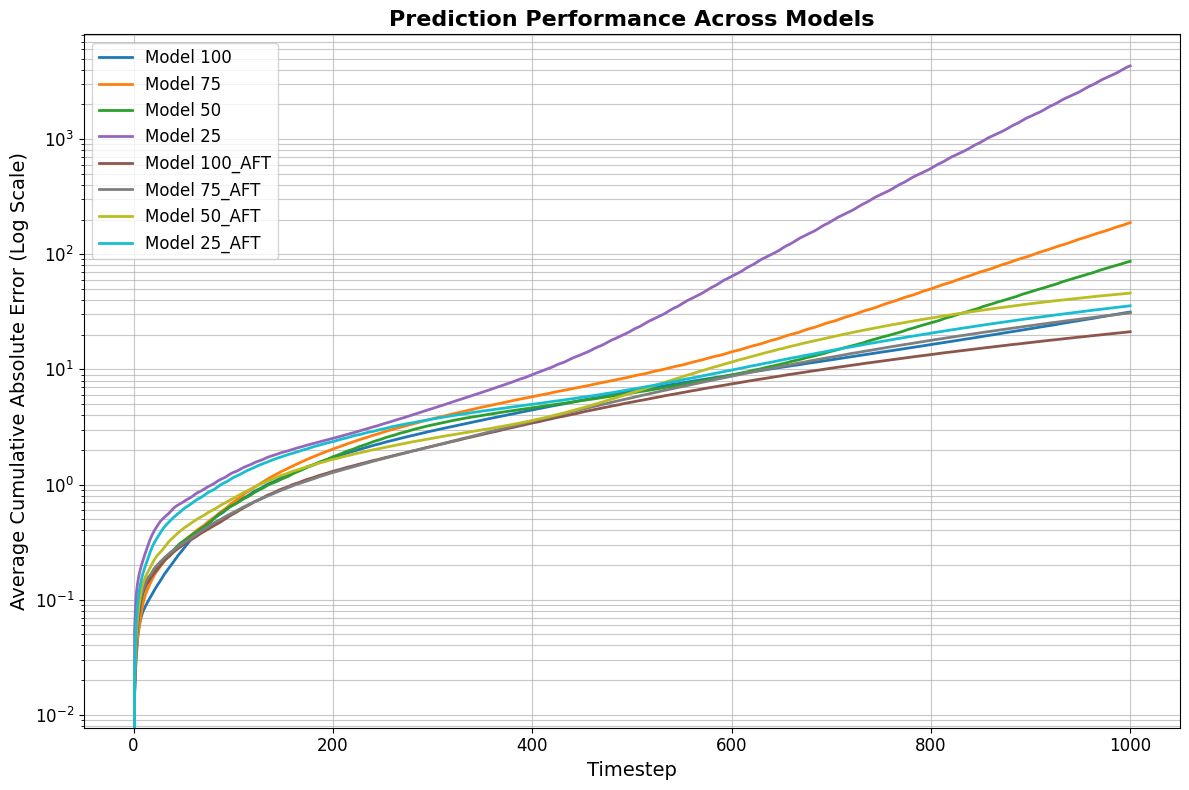

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils.data_loader import RepressilatorModel
import os

def generate_dataset(num_trajectories=1000, time_points=1001, time_span=200):
    """
    Generate a dataset of multiple trajectories from the Repressilator model.
    
    Args:
        num_trajectories: Number of trajectories to generate
        time_points: Number of time points in each trajectory
        time_span: Total time span for simulation
        
    Returns:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
        times: array of time points used for simulation
    """
    print(f"Generating {num_trajectories} trajectories...")
    trajectories = np.zeros((num_trajectories, time_points, 6))
    times = np.linspace(0, time_span, time_points)
    
    for i in tqdm(range(num_trajectories)):
        # Random initial conditions
        y0 = np.random.rand(6) * 100
        
        # Create model and simulate
        repressilator_model = RepressilatorModel(y0=y0)
        parameters = repressilator_model.suggested_parameters()
        traj = repressilator_model.simulate(parameters, times)
        
        # Normalize
        traj = traj/data_handler.Xscale
        
        # Store trajectory
        trajectories[i] = traj
        
    return trajectories, times

def evaluate_models(trajectories, models_dict, device="cuda"):
    """
    Evaluate multiple models on the generated trajectories using absolute cumulative error.
    
    Args:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
        models_dict: dictionary containing model and trainer pairs
        device: device to run computations on
        
    Returns:
        results: dictionary with evaluation metrics for each model
    """
    num_trajectories, time_points, _ = trajectories.shape
    results = {}
    
    for model_name, (_, trainer) in models_dict.items():
        print(f"Evaluating model: {model_name}")
        
        # Initialize arrays to store losses
        prediction_errors = np.zeros((num_trajectories, time_points))
        cumulative_errors = np.zeros((num_trajectories, time_points))
        
        # Evaluate each trajectory
        for i in tqdm(range(num_trajectories)):
            # Convert to tensor
            traj = torch.tensor(trajectories[i], dtype=torch.float32).to(device)
            
            # Get predicted trajectory
            predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)
            
            # Convert to numpy for error calculation
            traj_np = traj.cpu().detach().numpy()
            predicted_traj_np = predicted_traj.cpu().detach().numpy()
            
            # Calculate absolute error at each time step and make it cumulative
            cumulative_error = 0
            for t in range(time_points):
                # Single timestep absolute prediction error
                if t < len(predicted_traj_np):
                    # Mean absolute error across all state variables
                    error = np.mean(np.abs(traj_np[t] - predicted_traj_np[t]))
                    prediction_errors[i, t] = error
                    
                    # Add to cumulative error
                    cumulative_error += error
                    cumulative_errors[i, t] = cumulative_error
        
        # Calculate average errors across all trajectories
        avg_prediction_error = np.mean(prediction_errors, axis=0)
        avg_cumulative_error = np.mean(cumulative_errors, axis=0)
        
        # Store results
        results[model_name] = {
            'avg_prediction_error': avg_prediction_error,
            'avg_cumulative_error': avg_cumulative_error
        }
    
    return results

def plot_results(results, folder_path):
    """
    Plot the average cumulative absolute error for each model using a log scale.
    
    Args:
        results: dictionary with evaluation metrics for each model
        folder_path: path to save the plot
    """
    plt.figure(figsize=(12, 8))
    
    # Get the number of timesteps from the first model result
    timesteps = len(next(iter(results.values()))['avg_cumulative_error'])
    timestep_indices = np.arange(timesteps)
    
    # Define a color cycle for models
    colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
    
    # Plot cumulative absolute errors with log scale on y-axis
    for i, (model_name, metrics) in enumerate(results.items()):
        plt.semilogy(timestep_indices, metrics['avg_cumulative_error'], 
                     label=model_name, color=colors[i], linewidth=2)
    
    plt.xlabel('Timestep', fontsize=14)
    plt.ylabel('Average Cumulative Absolute Error (Log Scale)', fontsize=14)
    plt.title('Prediction Performance Across Models', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.7)
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    
    # Make sure folder exists
    os.makedirs(folder_path, exist_ok=True)
    
    plt.savefig(os.path.join(folder_path, 'model_prediction_comparison_log.png'), dpi=300)
    plt.show()

def evaluate_repressilator_models(models_trainers_dict, num_trajectories=1000, 
                                 time_points=1001, time_span=200, 
                                 device="cuda", folder_path="results", 
                                 save_dataset=True, save_results=False):
    """
    Main function to evaluate any number of model and trainer pairs on Repressilator trajectories,
    focusing on absolute cumulative prediction error.
    
    Args:
        models_trainers_dict: Dictionary with format {model_name: (model, trainer), ...}
        num_trajectories: Number of trajectories to generate
        time_points: Number of time points in each trajectory
        time_span: Total time span for simulation
        device: Device to run computations on
        folder_path: Path to save results and plots
        save_dataset: Whether to save the generated dataset
        save_results: Whether to save the evaluation results
        
    Returns:
        trajectories: Generated trajectories
        results: Evaluation results dictionary
    """
    # Generate dataset
    trajectories, times = generate_dataset(
        num_trajectories=num_trajectories, 
        time_points=time_points, 
        time_span=time_span
    )
    
    # Save the dataset if requested
    if save_dataset:
        # Make sure folder exists
        os.makedirs(folder_path, exist_ok=True)
        np.save(os.path.join(folder_path, 'repressilator_trajectories.npy'), trajectories)
        np.save(os.path.join(folder_path, 'repressilator_times.npy'), times)
        print(f"Dataset saved to {folder_path}")
    
    # Evaluate models
    results = evaluate_models(trajectories, models_trainers_dict, device)
    
    # Plot results
    plot_results(results, folder_path)
    
    # Save the results if requested
    if save_results:
        # Make sure folder exists
        os.makedirs(folder_path, exist_ok=True)
        np.save(os.path.join(folder_path, 'prediction_evaluation_results.npy'), results)
        print(f"Evaluation results saved to {folder_path}")
    
    return trajectories, results

# Example usage:
if __name__ == "__main__":
    # Create a dictionary of models and trainers
    # You can add any number of model-trainer pairs
    models_trainers_dict = {
        "Model 100": (model_100, trainer_100),
        "Model 75": (model_75, trainer_75),
        "Model 50": (model_50, trainer_50),
        "Model 25": (model_25, trainer_25),
        "Model 100_AFT": (model_100_AFT, trainer_100_AFT),
        "Model 75_AFT": (model_75_AFT, trainer_75_AFT),
        "Model 50_AFT": (model_50_AFT, trainer_50_AFT),
        "Model 25_AFT": (model_25_AFT, trainer_25_AFT)
    }
    
    # Evaluate all models
    trajectories, results = evaluate_repressilator_models(
        models_trainers_dict, 
        num_trajectories=10,  # Use more trajectories for final evaluation
        device=device,
        folder_path="results/repressilator_evaluation"
    )